**Problem Definition**

Main Problem

Predict traffic volume/congestion using historical traffic data.

Questions
What times have highest congestion?
Which factors affect traffic most?
Can machine learning accurately predict traffic flow?
Hypothesis

Traffic congestion depends on the Time and Day

In [19]:
import os
import pandas as pd

# Use project-relative dataset path
path = os.path.join(os.getcwd(), "Traffic_Dataset")

if not os.path.isdir(path):
    raise FileNotFoundError(f"Dataset folder not found: {path}")

print(path)
print(os.listdir(path))

/Users/youssefbarakat/Documents/GitHub/Big_Data_Project/Traffic_Dataset
['Traffic.csv', 'TrafficTwoMonth.csv']


In [20]:
df1 = pd.read_csv(os.path.join(path, "Traffic.csv"))
df2 = pd.read_csv(os.path.join(path, "TrafficTwoMonth.csv"))

In [21]:
#df1[:10]
#df2[:10]
df = pd.concat([df1, df2], ignore_index=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df[:10]

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal
5,1:15:00 AM,10,Tuesday,44,0,5,4,53,low
6,1:30:00 AM,10,Tuesday,37,0,1,4,42,low
7,1:45:00 AM,10,Tuesday,42,4,4,5,55,low
8,2:00:00 AM,10,Tuesday,51,0,9,7,67,low
9,2:15:00 AM,10,Tuesday,34,0,4,7,45,low


In [22]:
df.isnull().sum()

Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64

In [23]:
#Data Uncleaning
import numpy as np
for col in df.columns:
    null_indices = np.random.choice(df.index, 10, replace=False)
    df.loc[null_indices, col] = np.nan
df.isnull().sum()

Time                 10
Date                 10
Day of the week      10
CarCount             10
BikeCount            10
BusCount             10
TruckCount           10
Total                10
Traffic Situation    10
dtype: int64

In [24]:
df.dropna(inplace=True)
df.isnull().sum()

Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64

In [25]:
df.info()
df.describe()
print(df.shape)

<class 'pandas.DataFrame'>
Index: 6235 entries, 0 to 6323
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time               6235 non-null   str    
 1   Date               6235 non-null   float64
 2   Day of the week    6235 non-null   str    
 3   CarCount           6235 non-null   float64
 4   BikeCount          6235 non-null   float64
 5   BusCount           6235 non-null   float64
 6   TruckCount         6235 non-null   float64
 7   Total              6235 non-null   float64
 8   Traffic Situation  6235 non-null   str    
dtypes: float64(6), str(3)
memory usage: 487.1 KB
(6235, 9)


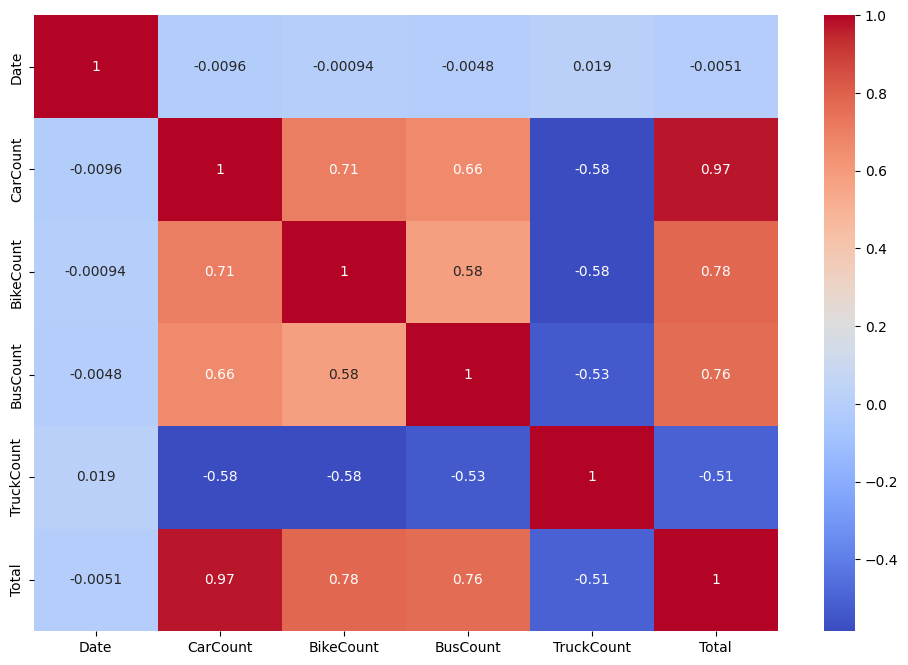

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

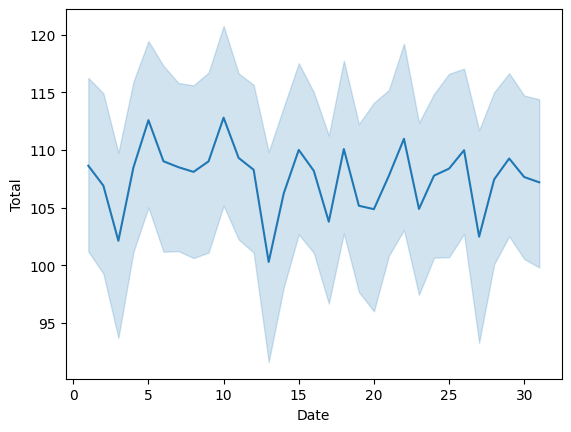

In [27]:
sns.lineplot(x='Date',
             y='Total',
             data=df)
plt.show()

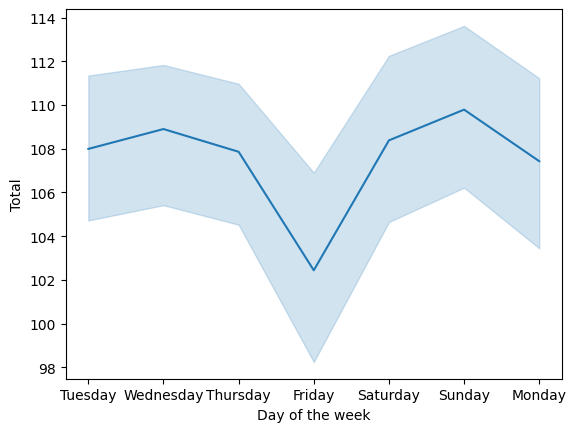

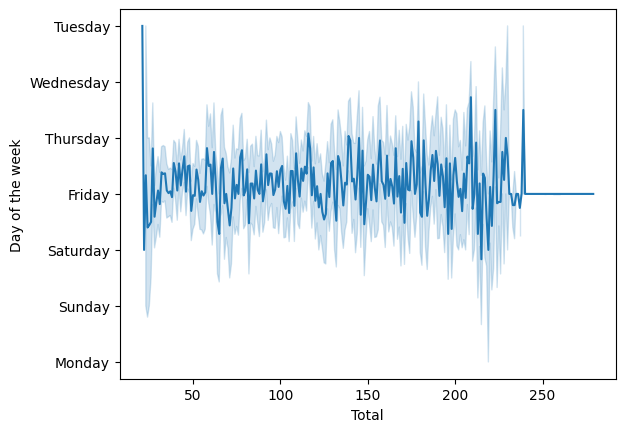

In [28]:
sns.lineplot(x='Day of the week',y='Total',data=df)
plt.show()
sns.lineplot(x='Total',y='Day of the week',data=df)
plt.show()

In [29]:
df['Time'] = pd.to_datetime(df['Time'])

df['Time'] = (
    df['Time'].dt.hour +
    df['Time'].dt.minute / 60
)

/var/folders/ph/90hk2k6939q3csdkd211f59c0000gn/T/ipykernel_23743/3096402891.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


In [37]:
from sklearn.model_selection import train_test_split

# Build feature matrix and target
model_df = df.copy()

# Convert date to numeric parts if present
if 'Date' in model_df.columns:
    model_df['Date'] = pd.to_datetime(model_df['Date'], errors='coerce')
    model_df['Date_year'] = model_df['Date'].dt.year
    model_df['Date_month'] = model_df['Date'].dt.month
    model_df['Date_day'] = model_df['Date'].dt.day
    model_df = model_df.drop(columns=['Date'])

# Remove rows with missing target
model_df = model_df.dropna(subset=['Total'])

# One-hot encode non-numeric columns
X = pd.get_dummies(model_df.drop(columns=['Total']), drop_first=True)
y = model_df['Total']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 2.946444656467905e-14
MSE: 1.2578858425949827e-27
